In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

import re

from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler # one hot encoder will result in multiple binary columns. ordinal encoder=> single column of integers. thus , reduces diamensionality. we use ordinal when categories have natural order. categories are just labels=> use ohe
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge #ridge is used and not lasso bcz there are many features and most of them are very relevant. ridge = a regularisation technique- shrinks all coefficients, but keeps every feature in the model. ridge is used here bcz, when there is multi collinearity(some features are highle correlated), lasso picks one among those features randomly and drops the other.; ridge- divides the weight equally to both of them. even useless features stay, just with smaller weights
# from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from scipy.optimize import nnls

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb #we use gradient boodting bcz of better accuracy than a single decision tree, works nicely without much preprocessing

SEED = 42
np.random.seed(SEED) # fixing the seed for np.random... np.random.rand(5)

# 2. Data loading

In [4]:
train=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test=pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
test_ids = test['TransactionID'].copy() #shd be preserved for submission

In [5]:
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
train.head(3)

Train shape: (138701, 50)
Test shape:  (15000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [6]:
#data type of each column and no. of null values of each col.
info_df=pd.DataFrame({
    'dtype':train.dtypes,
    'null_count':train.isnull().sum(),
    'n_unique':train.nunique(),
    'null_pct':(train.isnull().sum()/len(train)*100).round(2)
})

print(info_df.to_string()) #prints the full table. By default, pandas truncates large dataframes when printing — it shows ... in the middle if there are too many rows.

                             dtype  null_count  n_unique  null_pct
TransactionID                int64           0    138701      0.00
TargetValue                float64           0       675      0.00
AssetID                      int64           0    120111      0.00
ProductConfigID              int64           0      3594      0.00
DataOriginCode              object           0         6      0.00
VendorPartnerID             object           0        31      0.00
ManufactureYear              int64           0        68      0.00
OperationalHoursMeter      float64       56643     14643     40.84
UtilizationTier             object       88226         3     63.61
TransactionDate             object           0      3676      0.00
Spec_FullDescriptor         object           0      3505      0.00
Spec_BaseClass              object           0      1249      0.00
Spec_SubClass               object       36985       147     26.67
Spec_ReleaseSeries          object      105805       113     7

In [7]:
train.describe().T #numeric statistics

,count,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,2.186276e+06,1.128497e+06,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,4.152187e+04,2.636113e+04,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,1.204814e+06,5.287376e+05,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,7.286422e+03,7.542422e+03,39.0,1693.0,3852.0,11873.0,37209.0
ManufactureYear,138701.0,1.891641e+03,3.069920e+02,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,4.553719e+03,2.792204e+04,0.0,0.0,1620.0,5001.0,1729600.0


# 3. EDA

Goal here is to understand the shape of the target, which features look related to it, and what data-quality issues (missingness, skew) need handling before modelling.

**Distribution of target**

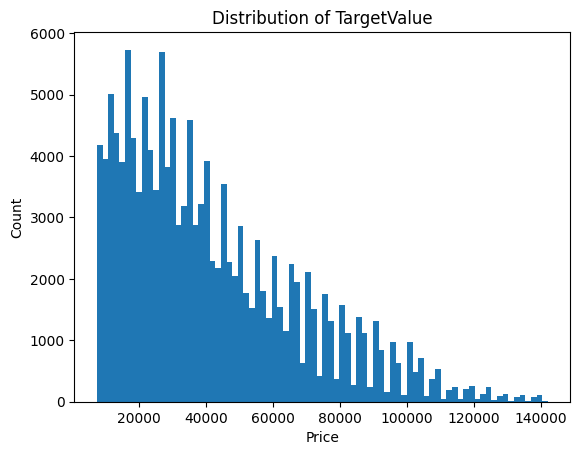

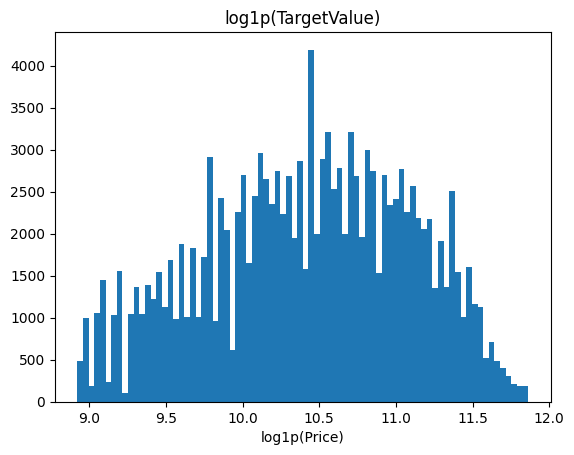

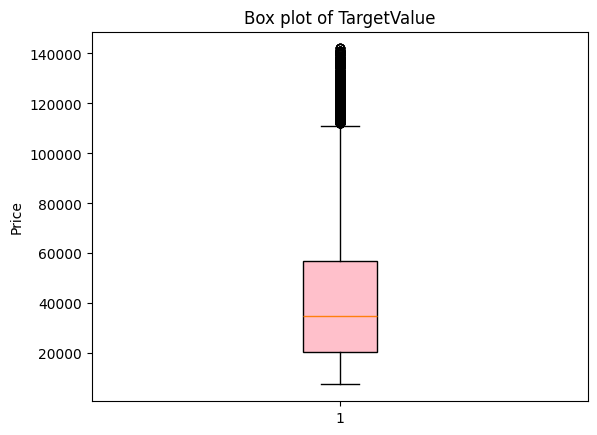

In [8]:
plt.hist(train['TargetValue'], bins=80) 
plt.title('Distribution of TargetValue')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

#log dist. of target
log_target = np.log1p(train['TargetValue']) # log1p(x)=log(x+1), to avoid log 0. used bcz error is calc. using RMSLE here
plt.hist(log_target, bins=80)
plt.title('log1p(TargetValue)')
plt.xlabel('log1p(Price)')
plt.show()

plt.boxplot(train['TargetValue'],patch_artist=True,boxprops=dict(facecolor='pink')) 
plt.title('Box plot of TargetValue')
plt.ylabel('Price')
plt.show()


TargetValue is heavily right-skewed; the log-transformed version is close to symmetric. Since the metric is RMSLE, training on log1p(TargetValue) with MSE is the same as optimising RMSLE directly. Every model in this notebook trains on the log target.

**Numeric feature distributions**

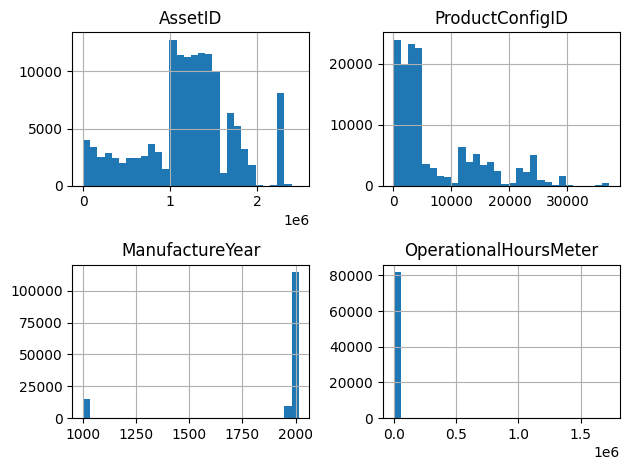

In [9]:
num_cols_all = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols_all = [c for c in num_cols_all if c not in ['TransactionID', 'TargetValue']]

train[num_cols_all].hist(bins=30)
plt.tight_layout()
plt.show()

The numeric column, OperationalHoursMeter, is strongly right-skewed the same way as the target is. That's the motivation for log-transforming OperationalHoursMeter specifically in Feature Engineering. It might have a direrct relationship to TargetValue.

**Missing values**

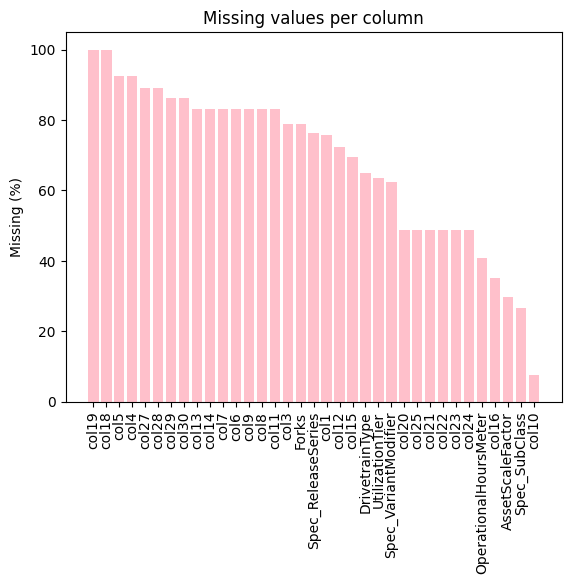

Columns with >80% missing: 15
Columns with >50% missing: 24


In [10]:
miss_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

plt.bar(miss_pct.index, miss_pct.values,color='pink') #index gives the column name, values -missing %. bar plot always requires 2 params
plt.xticks(rotation=90)
plt.ylabel('Missing (%)')
plt.title('Missing values per column')
plt.show()

print(f"Columns with >80% missing: {(miss_pct > 80).sum()}")
print(f"Columns with >50% missing: {(miss_pct > 50).sum()}")

Dropping rows with any missing value would throw away most of the dataset, and dropping the sparsest columns entirely would throw away potentially useful signal (a value being absent can itself be informative). I imputed (median for numeric, a 'missing' category for categorical) rather than drop, and added explicit missingness-flag columns for the sparsest spec fields so the model can use "was this present at all" as its own signal.

**Manufacture year**

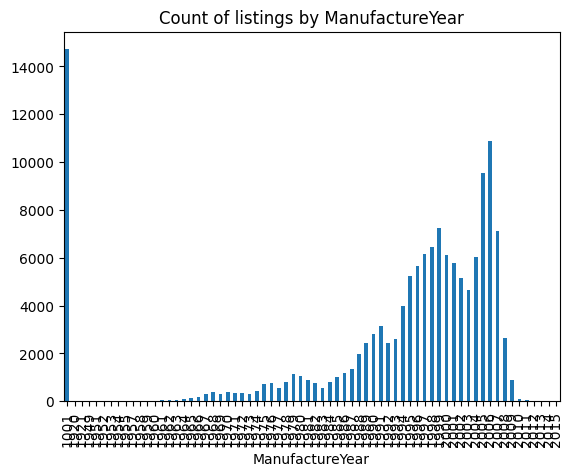

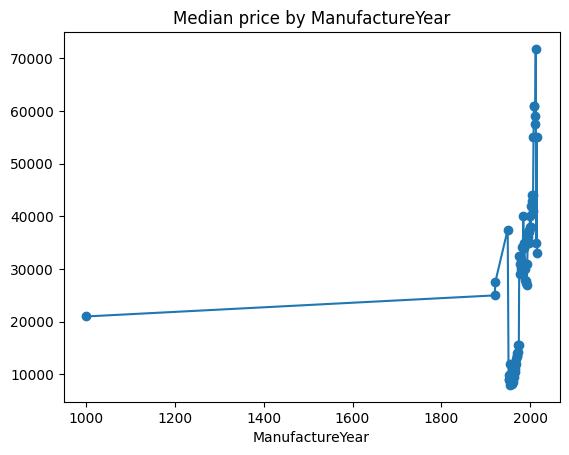

In [11]:
train['ManufactureYear'].value_counts().sort_index().plot(kind='bar')
plt.title('Count of listings by ManufactureYear')
plt.show()

yr_price = train.groupby('ManufactureYear')['TargetValue'].median()
yr_price.plot(marker='o')
plt.title('Median price by ManufactureYear')
plt.show()

In [12]:
#train['ManufactureYear'].value_counts()

The year 1001 is outside the real range and is clearly not genuine manufacture year — these must be treated as missing in Feature Engineering rather than as extremely old equipment (which would lead to wrong the EquipmentAge calculation).

**Operational Hour vs Price**
Checking if more hours on a machine means lower price

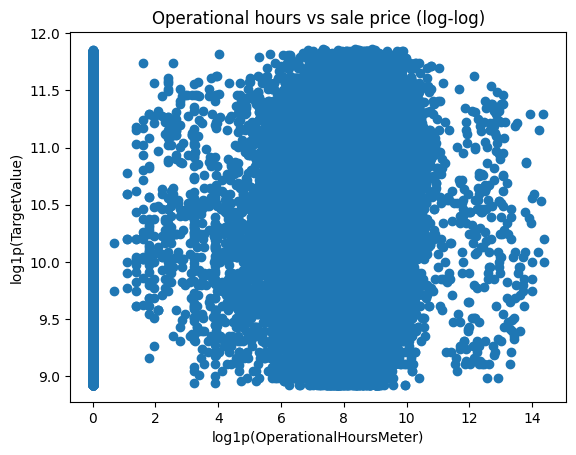

Correlation (raw):   0.002
Correlation (log1p): 0.017


In [13]:
sample = train.dropna(subset=['OperationalHoursMeter', 'TargetValue'])

plt.scatter(np.log1p(sample['OperationalHoursMeter']), np.log1p(sample['TargetValue']))
plt.xlabel('log1p(OperationalHoursMeter)')
plt.ylabel('log1p(TargetValue)')
plt.title('Operational hours vs sale price (log-log)')
plt.show()

raw_corr = sample[['OperationalHoursMeter', 'TargetValue']].corr().iloc[0, 1]
log_corr = pd.DataFrame({
    'log_hours': np.log1p(sample['OperationalHoursMeter']),
    'log_target': np.log1p(sample['TargetValue'])
}).corr().iloc[0, 1]

print(f'Correlation (raw):   {raw_corr:.3f}')
print(f'Correlation (log1p): {log_corr:.3f}')

The log-log correlation is stronger than the raw correlation, confirming the relationship is multiplicative rather than linear. This is another reason why LogOperationalHours (not the raw hours) goes into the model as a feature.

**Categorical features vs Price**

Top-10 categories (by median price) for categorical columns, to see which categories sell for more price.

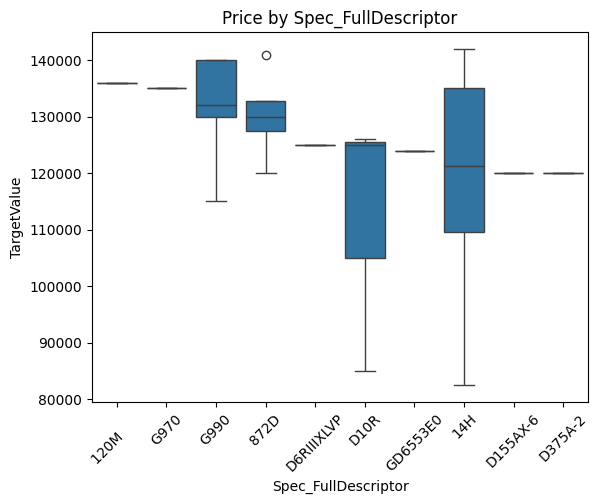

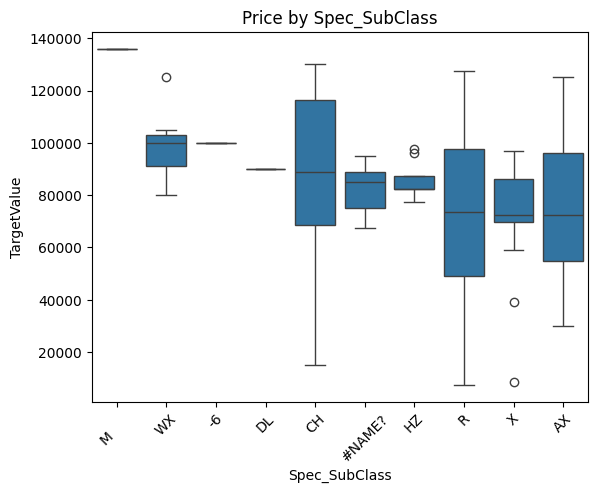

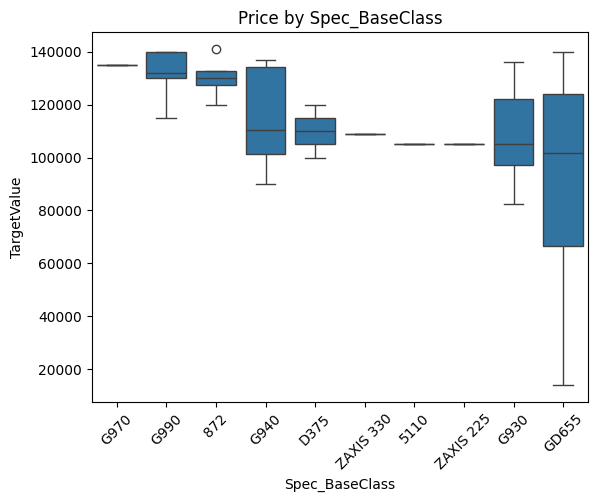

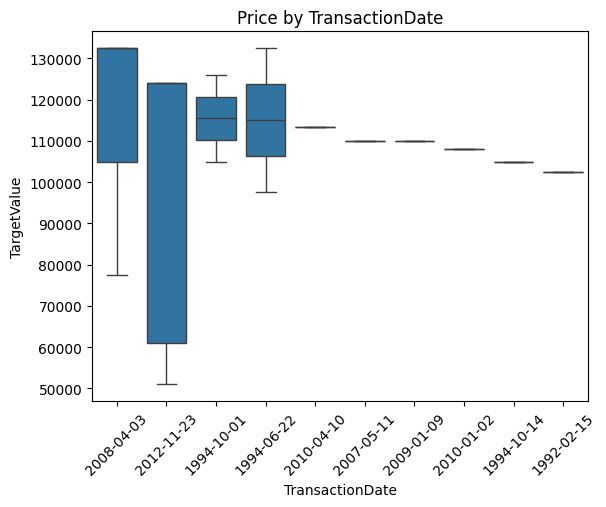

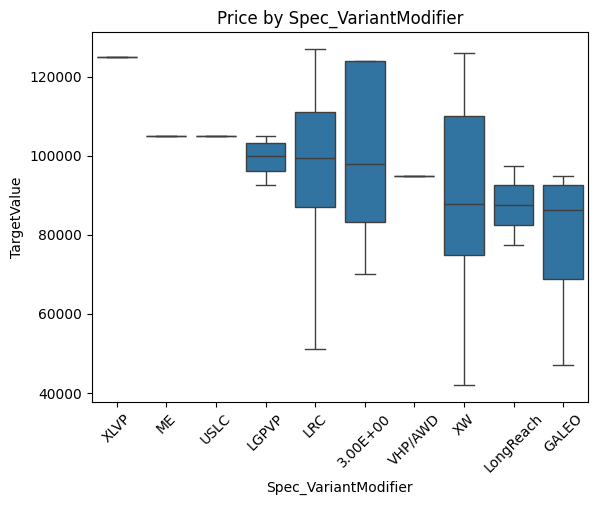

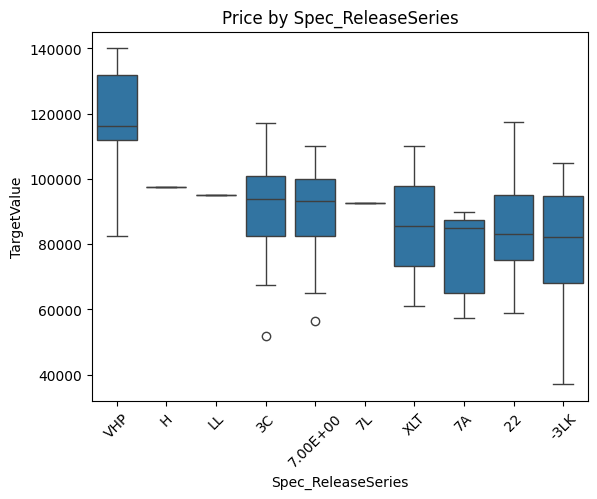

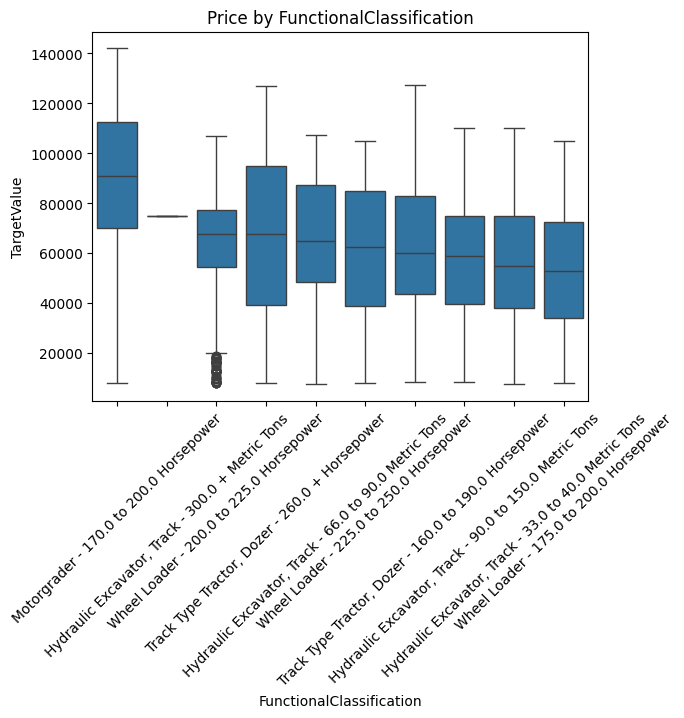

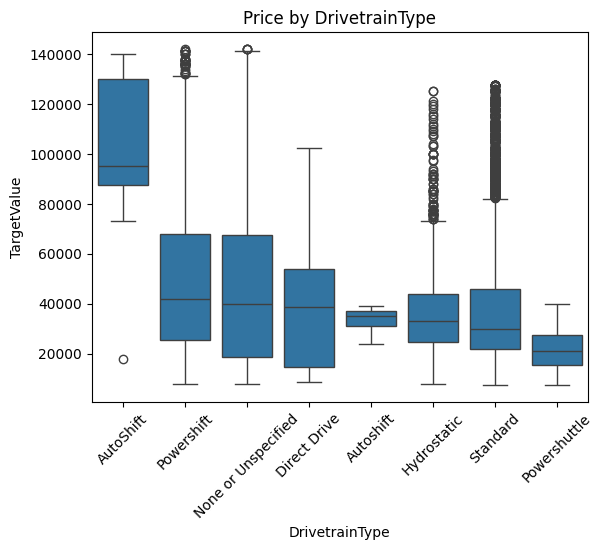

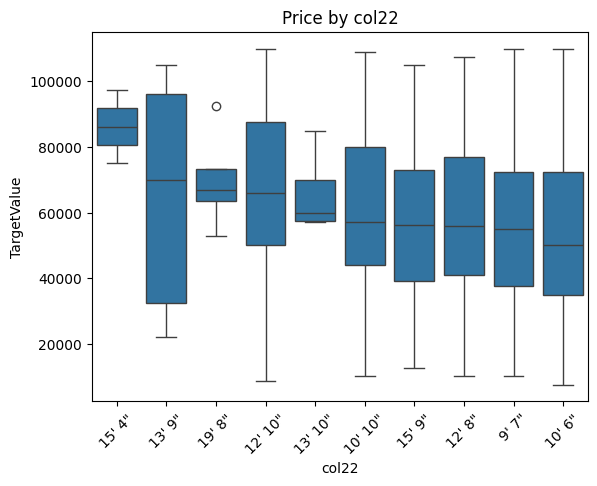

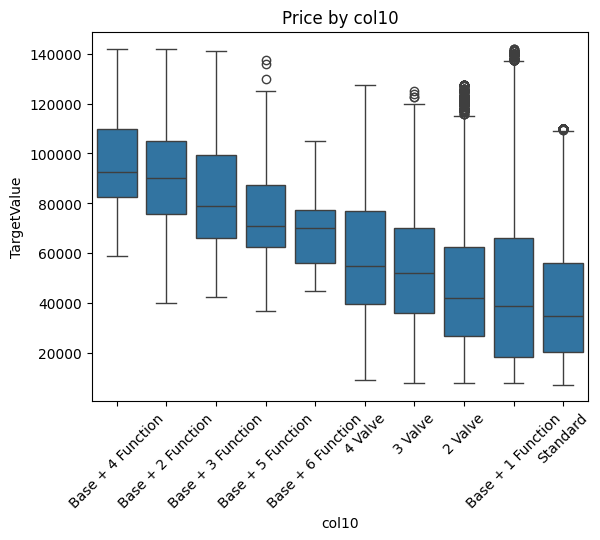

In [14]:
cat_cols = train.select_dtypes(include='object').columns.tolist()

spread = {}
for col in cat_cols:
    medians = train.groupby(col)['TargetValue'].median() # median of TargetValue per unique value of each cat. col.
    spread[col] = medians.max() - medians.min()

top10_cat_cols = sorted(spread, key=spread.get, reverse=True)[:10] # spread.get looks up each col. name's value in the dictionary.
# top10_cat_cols, is list of the 10 column names whose categories show the biggest difference in median price i.e., the columns most likely to matter for predicting price.

for col in top10_cat_cols:
    order = (train.groupby(col)['TargetValue'].median()
             .sort_values(ascending=False).index[:10])
    
    sns.boxplot(data=train[train[col].isin(order)], x=col, y='TargetValue', order=order)
    plt.title(f'Price by {col}')
    plt.xticks(rotation=45)
    plt.show()

Clear median-price gaps between categories in these columns. Hence, worth encoding them rather than dropping, since "which category" carries real price information.

**Price vs time**

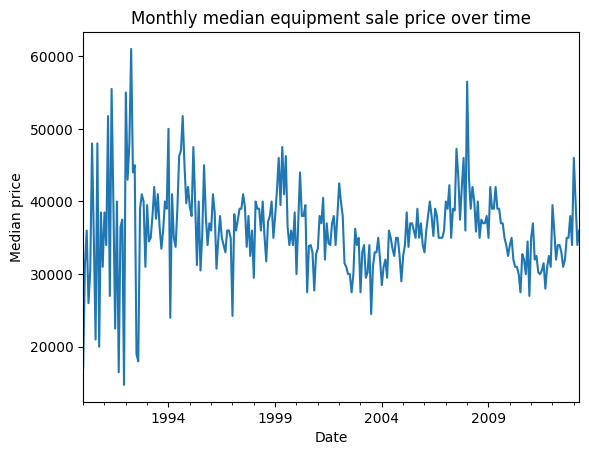

In [15]:
_train_dates = pd.to_datetime(train['TransactionDate'], errors='coerce') # converts the date column to actual datetime objects 
monthly = train.assign(TransactionDate=_train_dates).set_index('TransactionDate').resample('M')['TargetValue'].median()

monthly.plot()
plt.title('Monthly median equipment sale price over time')
plt.ylabel('Median price')

plt.xlabel('Date')
plt.show()

There is visible change over time. TransactionDate has to be broken into SaleYear/SaleMonth/SaleQuarter/SaleDayOfWeek rather than being dropped, with SaleMonth cyclically encoded so that December and January are read as "close" to the model.

**Correlation btw num. features**

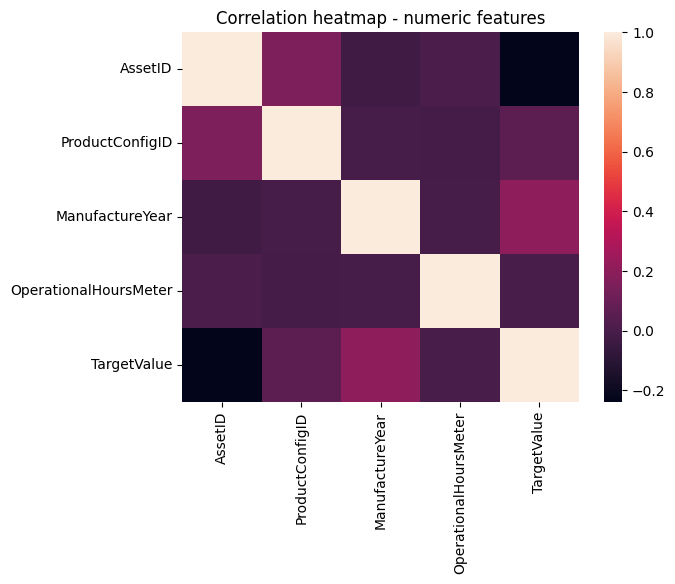

In [16]:
corr_matrix = train[num_cols_all + ['TargetValue']].corr()
sns.heatmap(corr_matrix)
plt.title('Correlation heatmap - numeric features')
plt.show()

* ManufactureYear vs TargetValue - lighter cell, suggesting a moderate positive correlation. This makes sense: newer equipment tends to sell for more price.
* AssetID vs TargetValue — very dark cell, suggesting a correlation close to 0. This makes sense — AssetID is just an identifier, not something that would meaningfully relate to price.
* ProductConfigID vs TargetValue and OperationalHoursMeter vs TargetValue — both look dark purple, suggesting weak correlation (close to 0) with price.
* Everything off the diagonal are dark coluured, meaning numeric features are not strongly correlated with each other. Highly correlated features (multicollinearity) can cause issues in models such as linear and logistic regression and even for tree based models, while predicting the feature importances.

**Price vs inventory grp**

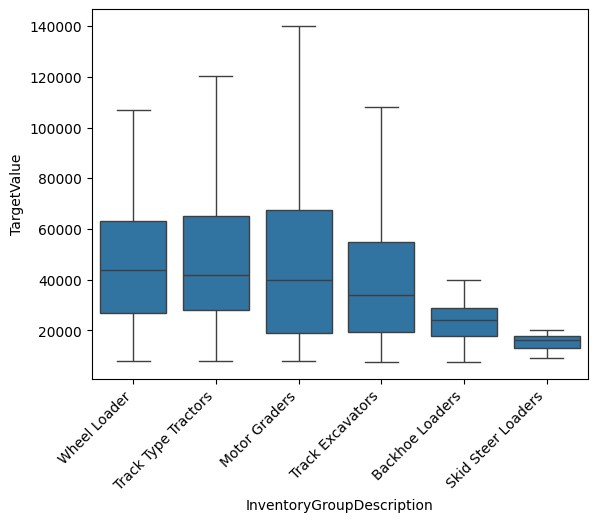

In [17]:
top_grps=train.groupby('InventoryGroupDescription')['TargetValue'].median().sort_values(ascending=False).head(15).index

sns.boxplot(data=train[train['InventoryGroupDescription'].isin(top_grps)],x='InventoryGroupDescription',y='TargetValue',order=top_grps,showfliers=False) # individual dots, representing outliers => showfliers
plt.xticks(rotation=45, ha='right') # ha=right => label text ends right at the tick, angling up-and-back from there
plt.show()

* Motor Graders and Track Excavators have the widest price range, with some units going as high as 140,000. This tells us these categories aren't one-size-fits-all — pricing probably depends a lot on factors like model, size, or age within the group.
* Skid Steer Loaders and Backhoe Loaders, on the other hand, are much more predictable — their prices stay within a narrow, consistent range.
Track Type Tractors stands out for a different reason: there's a cluster of outliers around 120,000–130,000, which likely points to a few premium or high-     end models pushing prices well above the rest of the group.
* Overall, this suggests InventoryGroupDescription is a genuinely useful feature for predicting price — the equipment types are clearly distinguishable in both typical price level and how much that price varies.

**OPERATIONAL HOURS**

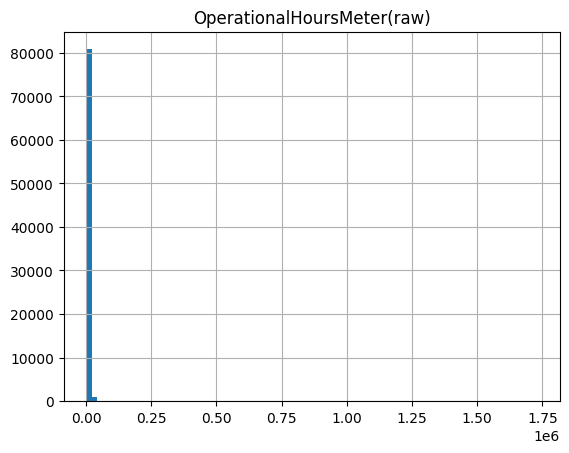

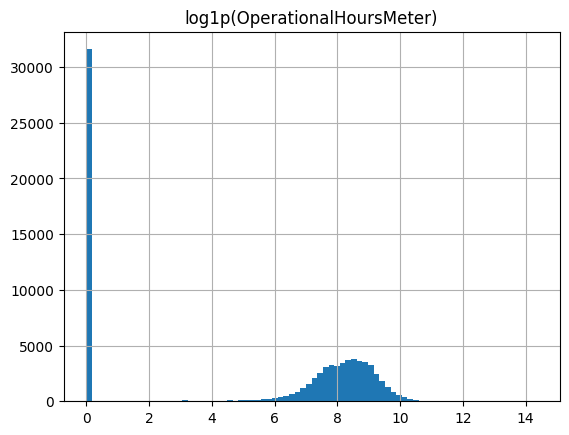

skew (raw):  33.28163987858272
skew (log1p): -0.3427086579635634


In [18]:
train['OperationalHoursMeter'].dropna().hist(bins=80)
plt.title('OperationalHoursMeter(raw)')
plt.show()

np.log1p(train['OperationalHoursMeter'].dropna()).hist(bins=80)
plt.title('log1p(OperationalHoursMeter)')
plt.show()

print('skew (raw): ', skew(train['OperationalHoursMeter'].dropna()))
print('skew (log1p):', skew(np.log1p(train['OperationalHoursMeter'].dropna())))

A negative skew means the distribution has a longer tail on the left side (toward lower values).

**Cardinality check on the ID-like columns**

In [19]:
print(train['AssetID'].nunique())
print(train['ProductConfigID'].nunique())
print(train['TransactionID'].nunique())
print(len(train))

print('numer of repeatitions in AssetID: ',-(train['AssetID'].nunique())+len(train))
print('number of repeatitions in ProductConfigID: ', -(train['ProductConfigID'].nunique())+len(train))

120111
3594
138701
138701
numer of repeatitions in AssetID:  18590
number of repeatitions in ProductConfigID:  135107


* AssetID has 120,111 unique values across 138,701 rows — meaning 18,590 rows are repeat sales of the same physical asset. That's real signal and hence sshouldnot be dropped.
* ProductConfigID (3,594 unique values) is also moderate-cardinality and might encode exact spec combos tightly tied to price — should not be dropped.
* Both are too high-cardinality for one-hot/ordinal encoding to work well, so I target-encoded instead of dropping.

**EDA summary**

* TargetValue is heavily right-skewed → train on the log-transformed target.
* Placeholder values in ManufactureYear (1000/1001) need to be nulled out before computing EquipmentAge.
* OperationalHoursMeter is right-skewed and relates to price multiplicatively, not linearly. I used its log.
* TransactionDate shows real drift over time. I decomposed into year/month/quarter/day-of-week, with cyclical encoding for month.
* Several categorical columns show large median-price gaps between categories. I encoded them, didnot drop.
* AssetID / ProductConfigID are high-cardinality but carry real price signal. I target-encoded them.
* Missingness is widespread (whole columns missing >50%) → impute + missingness flags.

## 4. Feature engineering and preprocessing

In [20]:
target='TargetValue'
y_raw=train[target].copy()# copy bcz, changing this shdnt affect the orgnl
y=np.log1p(y_raw)

allData=pd.concat([train.drop(columns=[target]),test],axis=0).reset_index(drop=True)#axis=0=>concatenate the cells vertically, ie., one cell below the other, for the cols common to both 
#reset_index => if we skip this, idxs will be 0,0,1,1,2,2..  ; drop=True=> discards old idx instead of inserting a new col.

print(f'combined shape: {allData.shape}')
n_train = len(train)   

combined shape: (153701, 49)


I am combining train and test before encoding so that the encoder sees all possible categories and does not crash on unseen values in test.

In [21]:
allData['TransactionDate']=pd.to_datetime(allData['TransactionDate'], errors='coerce')#errors='coerce' tells pandas that if a value cant be a valid date, treat it as NaT, eq. to NaN
allData['SaleYear']=allData['TransactionDate'].dt.year
allData['SaleMonth']=allData['TransactionDate'].dt.month
allData['SaleQuarter']=allData['TransactionDate'].dt.quarter
allData['SaleDayOfWeek']=allData['TransactionDate'].dt.dayofweek
allData.drop(columns=['TransactionDate'], inplace=True)

allData['ManufactureYear'] = allData['ManufactureYear'].replace([1000, 1001], np.nan) # placeholder yrs from eda

allData['EquipmentAge']=allData['SaleYear']-allData['ManufactureYear']#age of machine
allData['EquipmentAge']=allData['EquipmentAge'].clip(lower=0)#no negative age

allData['LogOperationalHours'] = np.log1p(allData['OperationalHoursMeter'].clip(lower=0))

#getting a number out of Spec_BaseClass
allData['SpecBaseNum'] = pd.to_numeric(
    allData['Spec_BaseClass'].astype(str).str.extract(r'(\d+)')[0], #as type(str) is reqd so that null values will be converted to "nan"
    errors='coerce'
)#/d+=>one or more digits. extract returns a datafram=>[0] selects one col. converts extracted string to actual numbers

allData['HoursPerYear'] = allData['OperationalHoursMeter'] / (allData['EquipmentAge'] + 1)
allData['BaseClass_Region'] = allData['Spec_BaseClass'].astype(str) + '_' + allData['RegionCode'].astype(str)

drop_cols = ['TransactionID'] # all values in thes col r unique
for c in drop_cols:
    if c in allData.columns:
        allData.drop(columns=c,inplace=True)

print('Final shape:', allData.shape)

Final shape: (153701, 56)


In [22]:
missing_pct = allData.isnull().mean() * 100   # % missing per column
sparse_spec_cols = missing_pct[missing_pct > 80].index.tolist()   # column names above 80%
print(sparse_spec_cols)

#sparse_spec_cols = ['col18', 'col19', 'col5', 'col4', 'col27', 'col28']
for c in sparse_spec_cols:
    if c in allData.columns:
        allData[c + '_missing'] = allData[c].isna().astype(int) # 0-missing, 1- present

allData['SaleMonth_sin'] = np.sin(2 * np.pi * allData['SaleMonth'] / 12)
allData['SaleMonth_cos'] = np.cos(2 * np.pi * allData['SaleMonth'] / 12) # x and y coords.

['col4', 'col5', 'col6', 'col7', 'col8', 'col9', 'col11', 'col13', 'col14', 'col18', 'col19', 'col27', 'col28', 'col29', 'col30']


Sometimes whether a value exists tells the model something, separate from what the value actually is.

Everything above this was row-wise so it's fine on the combined df. Everything below (AssetID_saleCount, encoding, imputing, target encoding) fits on train_fe only and gets applied to test_fe.

In [23]:
train_fe = allData.iloc[:n_train].reset_index(drop=True)
test_fe  = allData.iloc[n_train:].reset_index(drop=True)

asset_counts = train_fe['AssetID'].value_counts()
train_fe['AssetID_saleCount'] = train_fe['AssetID'].map(asset_counts)
test_fe['AssetID_saleCount']  = test_fe['AssetID'].map(asset_counts).fillna(1) # If a test asset was never seen during training, .map() can't find it in the table and returns nothing (NaN), so .fillna(1)

print(train_fe.shape, test_fe.shape)

(138701, 74) (15000, 74)


In [24]:
def encode_and_impute(df, cat_cols, num_cols, encoder=None, medians=None):
    df = df.copy()
    df[cat_cols] = df[cat_cols].fillna('missing')

    if encoder is None:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        encoder.fit(df[cat_cols])

    df[cat_cols] = encoder.transform(df[cat_cols]) # df[cat_cols] is a pandas Series - a single column of data — a one-dimensional labeled array.

    if medians is None:
        medians = df[num_cols].median() #train dataset => calc. median
    for col in num_cols:
        df[col] = df[col].fillna(medians[col]) # or without for loop df[num_cols] = df[num_cols].fillna(medians)

    return df, encoder, medians

# recompute cat_cols/num_cols since EquipmentAge, LogOperationalHours etc. were added above
cat_cols = train_fe.select_dtypes(include=['object']).columns.tolist()
num_cols = train_fe.select_dtypes(include=[np.number]).columns.tolist()

train_feat, fitted_encoder, fitted_medians = encode_and_impute(train_fe, cat_cols, num_cols)
test_feat, _, _ = encode_and_impute(test_fe, cat_cols, num_cols, encoder=fitted_encoder, medians=fitted_medians)

print('encoding + imputing done')
print(f'nulls left in train: {train_feat.isnull().sum().sum()}')
print(f'nulls left in test:  {test_feat.isnull().sum().sum()}')
train_feat.head(3)

encoding + imputing done
nulls left in train: 0
nulls left in test:  0


,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,...,col14_missing,col18_missing,col19_missing,col27_missing,col28_missing,col29_missing,col30_missing,SaleMonth_sin,SaleMonth_cos,AssetID_saleCount
0,117665,88,0.0,5.0,1997.0,4640.0,1.0,1198.0,326.0,48.0,...,1,1,1,1,1,0,0,1.000000e+00,6.123234e-17,1
1,1001282,4616,0.0,5.0,2005.0,508.0,1.0,325.0,100.0,50.0,...,1,1,1,1,1,1,1,-2.449294e-16,1.000000e+00,1
2,772709,1948,0.0,5.0,1994.0,11540.0,0.0,1000.0,257.0,43.0,...,1,1,1,1,1,1,1,-8.660254e-01,-5.000000e-01,2


One reusable fn for train and test so that nothing is computed twice

**K Fold Target Encoding**

Each category in the test dataset is replaced by the average target value (price) for that category in a particular col.

In [25]:
def kfold_target_encode(train_df, test_df, col, y, n_splits=5, seed=42, smoothing=20):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(train_df))
    global_mean = y.mean() # the average TargetValue across all of train. Used as a fallback for rare/unseen categories.

    for tr_idx, val_idx in kf.split(train_df): # tr_idx and val_idx are each a whole list of row numbers, not single index values
        means = y.iloc[tr_idx].groupby(train_df[col].iloc[tr_idx]).mean() # mean of each category in the col.
        counts = train_df[col].iloc[tr_idx].value_counts() 
        smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing) # This number controls how many rows' worth of trust a category needs before its own average starts to matter more than the global fallback. Higher smoothing = more conservative (pulls harder toward global average, needs more data before trusting a category's own number). Lower smoothing = less conservative (trusts small categories' own averages more readily, but risks overfitting to noise).
        oof[val_idx] = train_df[col].iloc[val_idx].map(smoothed).fillna(global_mean) # By the end of all 5 iterations, every row has been in val_idx exactly once — and each time, it got encoded using the means computed from the other 4 folds. That's what fills up the entire oof array with leakage-free values

    # full-train mapping for test set
    means = y.groupby(train_df[col]).mean()
    counts = train_df[col].value_counts()
    smoothed_full = (means * counts + global_mean * smoothing) / (counts + smoothing)
    test_enc = test_df[col].map(smoothed_full).fillna(global_mean)

    return oof, test_enc

cat_cols = train.select_dtypes(include='object').columns.tolist()

cardinality = train[cat_cols].nunique().sort_values(ascending=False)
#print(cardinality)

high_card_cols = ['Spec_FullDescriptor', 'InventoryGroupDescription', 'RegionCode',
                   'VendorPartnerID', 'DataOriginCode', 'Spec_SubClass',
                   'AssetID', 'ProductConfigID']

for col in high_card_cols:
    if col in train_feat.columns: # ensuring that it is not a col. obtained by feature engineering
        oof_te, test_te = kfold_target_encode(train_feat, test_feat, col, y)
        train_feat[col + '_te'] = oof_te
        test_feat[col + '_te'] = test_te # target encoding

for col in high_card_cols:
    if col in train_feat.columns:
        train_feat.drop(columns=col, inplace=True)
        test_feat.drop(columns=col, inplace=True)

cat_cols_remaining = [c for c in cat_cols if c in train_feat.columns]
print(train_feat.shape, test_feat.shape)

(138701, 74) (15000, 74)


In [26]:
# scaled copies, only needed for the ridge model (tree models dont care about scale, they just split on raw thresholds)
scaler = StandardScaler()
train_feat_scaled = pd.DataFrame(scaler.fit_transform(train_feat), columns=train_feat.columns, index=train_feat.index)
test_feat_scaled  = pd.DataFrame(scaler.transform(test_feat), columns=test_feat.columns, index=test_feat.index)


# Naive baseline

Just a DummyRegressor guessing the mean/median price for every row regardless of features.

In [27]:
from sklearn.dummy import DummyRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_rmsle_dummy(strategy):
    scores = []
    for tr_idx, val_idx in kf.split(train_feat):
        dummy = DummyRegressor(strategy=strategy) # predicts the same single value
        dummy.fit(train_feat.iloc[tr_idx], y.iloc[tr_idx])
        preds = dummy.predict(train_feat.iloc[val_idx])
        preds_orig = np.clip(np.expm1(preds), 0, None)
        y_orig = np.expm1(y.iloc[val_idx]) # expm1(x)=exp(x)-1
        scores.append(np.sqrt(mean_squared_log_error(y_orig, preds_orig)))
    return np.array(scores)

mean_scores   = cv_rmsle_dummy('mean')
median_scores = cv_rmsle_dummy('median')

print(f'Dummy (mean)   CV RMSLE: {mean_scores.mean():.4f} +/- {mean_scores.std():.4f}')
print(f'Dummy (median) CV RMSLE: {median_scores.mean():.4f} +/- {median_scores.std():.4f}')

baseline_rmsle = min(mean_scores.mean(), median_scores.mean())


Dummy (mean)   CV RMSLE: 0.6710 +/- 0.0014
Dummy (median) CV RMSLE: 0.6721 +/- 0.0015


# Hyperparameter tuning

For ridge I just used GridSearchCV since it only really has one knob (alpha) and the space is small enough to just brute force it.



In [28]:
param_dist_lgbm = {
    'num_leaves': [63, 127, 255, 400, 600],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'min_child_samples': [10, 15, 20, 30],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.05, 0.1, 0.5],
    'reg_lambda': [0, 0.05, 0.1, 0.5, 2],
}

search_sample = train_feat.sample(40000, random_state=SEED)
y_sample = y.loc[search_sample.index]

search_lgbm = RandomizedSearchCV(
    LGBMRegressor(n_estimators=300, random_state=SEED, n_jobs=1, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=2,
    random_state=SEED,
    n_jobs=-1,
)
search_lgbm.fit(search_sample, y_sample)
print("Best LGBM params:", search_lgbm.best_params_)
print("Best LGBM CV RMSE:", -search_lgbm.best_score_)

Best LGBM params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.05, 'num_leaves': 255, 'min_child_samples': 15, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best LGBM CV RMSE: 0.229078732069309


In [29]:
# param_dist_cat = {
#     'depth': [4, 6, 7, 8, 10],
#     'learning_rate': [0.01, 0.02, 0.03, 0.05],
#     'l2_leaf_reg': [1, 3, 5, 7, 9],
#     'subsample': [0.6, 0.7, 0.8, 0.9],
# }

# cat_search_est_params = dict(iterations=300, random_seed=SEED, verbose=False,
#                               bootstrap_type='Bernoulli', task_type='GPU')

# search_cat = RandomizedSearchCV(
#     CatBoostRegressor(**cat_search_est_params),
#     param_distributions=param_dist_cat,
#     n_iter=10,
#     scoring='neg_root_mean_squared_error',
#     cv=2,
#     random_state=SEED,
#     n_jobs=1,  
# )
# search_sample_cat = search_sample.copy()
# search_sample_cat[cat_cols_remaining] = search_sample_cat[cat_cols_remaining].astype(int)
# cat_col_indices_search = [search_sample_cat.columns.get_loc(c) for c in cat_cols_remaining]
# search_cat.fit(search_sample_cat, y_sample, cat_features=cat_col_indices_search)
# print("Best CatBoost params:", search_cat.best_params_)
# print("Best CatBoost CV RMSE:", -search_cat.best_score_)


In [30]:
param_dist_xgb = {
    'max_depth': [4, 6, 7, 8, 10],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.05, 0.1, 0.5],
    'reg_lambda': [0, 0.05, 0.1, 0.5, 2],
}

search_xgb = RandomizedSearchCV(
    XGBRegressor(n_estimators=300, random_state=SEED, n_jobs=1, tree_method='hist'),
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=2,
    random_state=SEED,
    n_jobs=-1,
)
search_xgb.fit(search_sample, y_sample)
print("Best XGB params:", search_xgb.best_params_)
print("Best XGB CV RMSE:", -search_xgb.best_score_)

Best XGB params: {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best XGB CV RMSE: 0.233218062362357


In [31]:
from sklearn.model_selection import GridSearchCV
param_grid_ridge = {'alpha': [0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]}

ridge_search_sample = train_feat_scaled.sample(40000, random_state=SEED)
y_ridge_sample = y.loc[ridge_search_sample.index]

search_ridge = GridSearchCV(
    Ridge(random_state=SEED), param_grid_ridge,
    scoring='neg_root_mean_squared_error', cv=5,
)
search_ridge.fit(ridge_search_sample, y_ridge_sample)
print("Best Ridge alpha:", search_ridge.best_params_)
print("Best Ridge CV RMSE:", -search_ridge.best_score_)

Best Ridge alpha: {'alpha': 30.0}
Best Ridge CV RMSE: 0.3390392594130981


# LightGBM + XGBoost + CatBoost

In [32]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

SEED = 42
np.random.seed(SEED)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

lgbm_params = dict(n_estimators=3000, learning_rate=0.05, num_leaves=255,
                    min_child_samples=15, subsample=0.8, subsample_freq=1,
                    colsample_bytree=0.6, reg_alpha=0.05, reg_lambda=0.1,
                    random_state=SEED, n_jobs=-1, verbose=-1)  # after HPT

use_gpu = True
try:
    import subprocess
    subprocess.check_output('nvidia-smi')
except Exception:
    use_gpu = False

xgb_params = dict(
    n_estimators=3000, learning_rate=0.05, max_depth=8,
    subsample=0.6, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=0.5,
    random_state=SEED, n_jobs=-1, early_stopping_rounds=100,
    tree_method='hist', device='cuda' if use_gpu else 'cpu')  # after HPT

cat_params = dict(iterations=3000, learning_rate=0.03, depth=10,
                   l2_leaf_reg=1, subsample=0.7, bootstrap_type='Bernoulli',
                   loss_function='RMSE', eval_metric='RMSE',
                   random_seed=SEED, early_stopping_rounds=100, verbose=False,
                   task_type='GPU' if use_gpu else 'CPU')  # after HPT

seeds = [42, 202, 2024]
n_seeds = len(seeds)
seed = seeds[0]

oof_lgbm = np.zeros(len(train_feat)); test_lgbm = np.zeros(len(test_feat))
oof_xgb  = np.zeros(len(train_feat)); test_xgb  = np.zeros(len(test_feat))
oof_cat  = np.zeros(len(train_feat)); test_cat  = np.zeros(len(test_feat))

cat_col_indices = [train_feat.columns.get_loc(c) for c in cat_cols if c in train_feat.columns]
cat_col_names   = [c for c in cat_cols if c in train_feat.columns]
train_feat_cat = train_feat.copy(); test_feat_cat = test_feat.copy()
train_feat_cat[cat_col_names] = train_feat_cat[cat_col_names].astype(int)
test_feat_cat[cat_col_names]  = test_feat_cat[cat_col_names].astype(int)

for seed in seeds:
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_feat)):
        X_tr, X_val = train_feat.iloc[tr_idx], train_feat.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        X_tr_cat, X_val_cat = train_feat_cat.iloc[tr_idx], train_feat_cat.iloc[val_idx]
    
        m_lgbm = LGBMRegressor(**{**lgbm_params, 'random_state': seed})
        m_lgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
           categorical_feature=cat_col_names,
           callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_lgbm[val_idx] += m_lgbm.predict(X_val) / n_seeds         # avg across seeds, correct as-is
        test_lgbm += m_lgbm.predict(test_feat) / (kf.n_splits*n_seeds )
    
        m_xgb = XGBRegressor(**{**xgb_params, 'random_state': seed})
        m_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        oof_xgb[val_idx] += m_xgb.predict(X_val) / n_seeds          # FIX: += / n_seeds, not =
        test_xgb += m_xgb.predict(test_feat) / (kf.n_splits*n_seeds)  # FIX: divide by 15, not 5
    
        m_cat = CatBoostRegressor(**{**cat_params, 'random_seed': seed}, cat_features=cat_col_indices)
        m_cat.fit(X_tr_cat, y_tr, eval_set=(X_val_cat, y_val))
        oof_cat[val_idx] += m_cat.predict(X_val_cat) / n_seeds    # FIX: += / n_seeds, not =
        test_cat += m_cat.predict(test_feat_cat) / (kf.n_splits *n_seeds)  # FIX: divide by 15, not 5

print("LGBM OOF:", np.sqrt(mean_squared_error(y, oof_lgbm)))
print("XGB  OOF:", np.sqrt(mean_squared_error(y, oof_xgb)))
print("Cat  OOF:", np.sqrt(mean_squared_error(y, oof_cat)))

LGBM OOF: 0.19888872207183833
XGB  OOF: 0.20140535701130616
Cat  OOF: 0.2059976788732641


In [33]:
from sklearn.linear_model import Ridge

stack_X = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
stack_test = np.column_stack([test_lgbm, test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(stack_X, y)
blend_oof = meta.predict(stack_X)
print("Stacked OOF RMSLE:", np.sqrt(mean_squared_error(y, blend_oof)))

test_pred_log = meta.predict(stack_test)

Stacked OOF RMSLE: 0.1978885162502729


# Submission

In [34]:
from scipy.optimize import nnls

oof_matrix = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
w, _ = nnls(oof_matrix, y.values)
#w = w / w.sum()
w1, w2, w3 = w
blend_oof = oof_matrix @ w
print(f"Weights -> LGBM: {w1:.3f} | XGB: {w2:.3f} | Cat: {w3:.3f}")
print(f"Blended OOF RMSLE: {np.sqrt(mean_squared_error(y, blend_oof)):.4f}")

test_matrix = np.column_stack([test_lgbm, test_xgb, test_cat])
test_pred_log = w1*test_lgbm + w2*test_xgb + w3*test_cat
test_pred = np.expm1(test_pred_log)

# clip to sane range based on train target distribution (new)
lo, hi = train[target].quantile(0.001), train[target].quantile(0.999)
test_pred = np.clip(test_pred, lo, hi)

submission = pd.DataFrame({'TransactionID': test_ids, 'TargetValue': np.round(test_pred, 2)})
submission.to_csv('submission.csv', index=False)
print("submission.csv saved:", submission.shape)

Weights -> LGBM: 0.645 | XGB: 0.327 | Cat: 0.027
Blended OOF RMSLE: 0.1979
submission.csv saved: (15000, 2)


In [35]:
# known_prices = np.sort(train[target].unique())

# def snap_to_known(preds, known):
#     idx = np.searchsorted(known, preds)
#     idx = np.clip(idx, 1, len(known) - 1)
#     left, right = known[idx - 1], known[idx]
#     return np.where(preds - left < right - preds, left, right)

# # check it actually helps OOF before trusting it on test
# oof_pred_raw = np.expm1(blend_oof)
# oof_pred_snapped = snap_to_known(oof_pred_raw, known_prices)
# print("OOF RMSLE raw:   ", np.sqrt(mean_squared_log_error(y_raw, np.clip(oof_pred_raw, 1e-6, None))))
# print("OOF RMSLE snapped:", np.sqrt(mean_squared_log_error(y_raw, np.clip(oof_pred_snapped, 1e-6, None))))